In [135]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [136]:
df= pd.read_csv('../Data/Historical Product Demand.csv')


In [137]:
df.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012/7/27,100
1,Product_0979,Whse_J,Category_028,2012/1/19,500
2,Product_0979,Whse_J,Category_028,2012/2/3,500
3,Product_0979,Whse_J,Category_028,2012/2/9,500
4,Product_0979,Whse_J,Category_028,2012/3/2,500


# Revision DataFrame

In [138]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  object
dtypes: object(5)
memory usage: 40.0+ MB


- Las fechas estan en formato incorrecto
- Existen nulos en card (?)

## Revision datos nulos

In [139]:
df.isnull().sum()

Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

In [140]:
print(f'La cantidad de nulos es {np.max(df.isnull().sum().values)} y el dataframe tiene {df.shape[0]}')

La cantidad de nulos es 11239 y el dataframe tiene 1048575


- En este caso debido a que la cantidad de nulos que representa casi un 1.1 % del total de los datos es correcto eliminarlos

In [141]:
df.dropna(subset=['Date'], inplace=True)

- Existen bastantes nulos los que eliminaremos
- Además también existen otros carácteres que no son números

## Revisando las variables categoricas y numericas si existen problemas

In [142]:
for col in df[['Product_Code', 'Warehouse', 'Order_Demand']].columns:

    print(df[col].unique)

<bound method Series.unique of 0          Product_0993
1          Product_0979
2          Product_0979
3          Product_0979
4          Product_0979
               ...     
1048570    Product_1791
1048571    Product_1974
1048572    Product_1787
1048573    Product_0901
1048574    Product_0704
Name: Product_Code, Length: 1037336, dtype: object>
<bound method Series.unique of 0          Whse_J
1          Whse_J
2          Whse_J
3          Whse_J
4          Whse_J
            ...  
1048570    Whse_J
1048571    Whse_J
1048572    Whse_J
1048573    Whse_J
1048574    Whse_J
Name: Warehouse, Length: 1037336, dtype: object>
<bound method Series.unique of 0           100 
1           500 
2           500 
3           500 
4           500 
           ...  
1048570    1000 
1048571       1 
1048572    2500 
1048573      50 
1048574       4 
Name: Order_Demand, Length: 1037336, dtype: object>


- La única columna que se ve con problemas seria `Order_demand` la que no es numérica y además tiene carácteres como paréntesis

### Eliminando los datos que no sean numeros de la columna order_demand

In [143]:
df['Order_Demand'] = df['Order_Demand'].str.replace(r'[^0-9]', '', regex=True).astype(int)


- Aprovechamos de después de sacar todos los datos no numericos convertir a integer, si está bien entonces no deberia tirar error.

In [144]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1037336 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1037336 non-null  object
 1   Warehouse         1037336 non-null  object
 2   Product_Category  1037336 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1037336 non-null  int32 
dtypes: int32(1), object(4)
memory usage: 43.5+ MB


## Convirtiendo Date a datetime

In [145]:
df['Date'] = pd.to_datetime(df['Date'])

In [146]:
df.set_index('Date', inplace=True)

# Revisando los estadisticos

In [147]:
df.describe().round(2)

,Order_Demand
count,1037336.00
mean,4949.38
std,29073.44
min,0.00
25%,20.00
50%,300.00
75%,2000.00
max,4000000.00


- Existen datos donde no hay ordenes lo que sugiere que fueron dias donde no se vendió nada.
- El 75 % de los datos se encuentra por debajo de 2000 ordenes pero el valor máximo es de 4000000 lo que es 1999 veces más grande
- En este punto no podriamos ver bien la distribucion ya que por este valor la diferencia de escalas no dejara revisar bien su distribución
     

## Revisando los valores de Order_Demand

C:\Users\kev_g\AppData\Local\Temp\ipykernel_10164\827725282.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(df['Order_Demand'], palette='pastel')


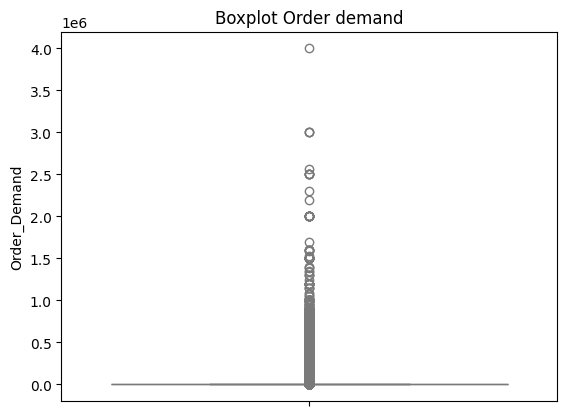

In [148]:
sns.boxplot(df['Order_Demand'], palette='pastel')
plt.title('Boxplot Order demand')
plt.show()


- El gráfico biene a confirmar lo que vimos anteriormente

In [149]:

# Función para revisar la cantidad de datos sobre el valor del valor ingresado
def datos_sobre_thrid_quantile(values: list):

    data = []

    for value in values:
        df_outliers = df[df['Order_Demand'] > value]

        data.append(df_outliers.shape[0])
    return data

datos_sobre_thrid_quantile([2000, 10000, 20000, 1000000])


[235518, 74350, 43741, 76]

- Al parecer los valores grandes no son valores mal ingresados ya que existen bastantes valores después del cuartil 3.

In [150]:
df['Order_Demand_log'] = np.log1p(df['Order_Demand'])

<Axes: xlabel='Order_Demand_log', ylabel='Count'>

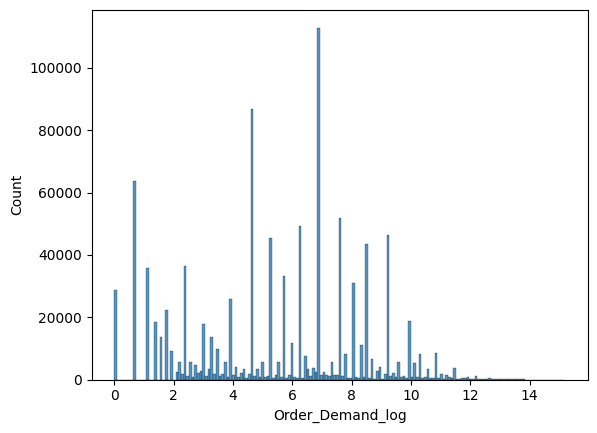

In [151]:
sns.histplot(df['Order_Demand_log'])

In [152]:
y = df['Order_Demand'].resample('W-MON').mean()




In [153]:
y = y.ffill()

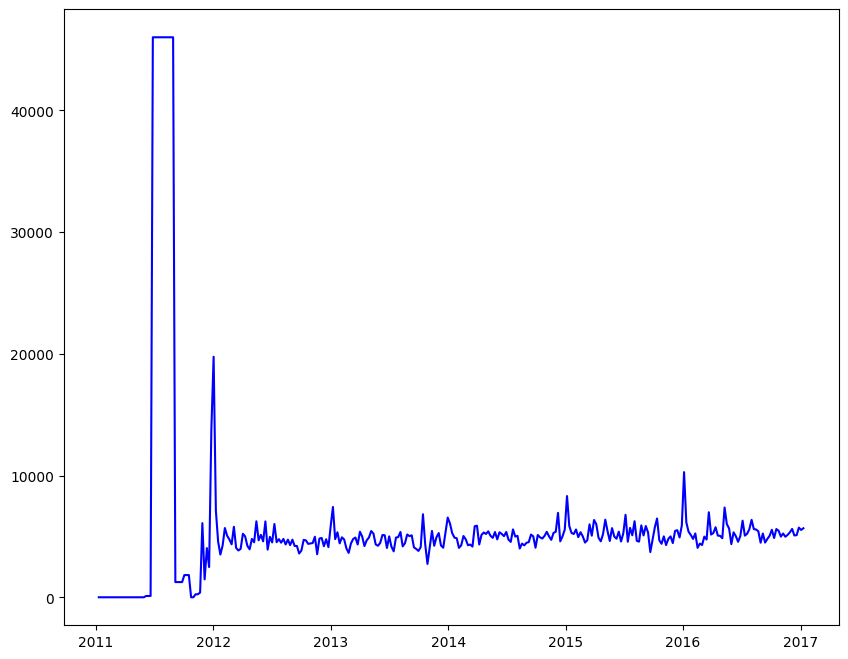

In [154]:
plt.figure(figsize=(10, 8))
plt.plot(y.index, y, label='Datos Originales', color='blue')
plt.show()


- Considerando que los datos no se ven prometedores con el valor máximo, tomaremos desde finales del 2019 en adelante

In [155]:
y = y[y.index > pd.to_datetime('2012-12-01')]


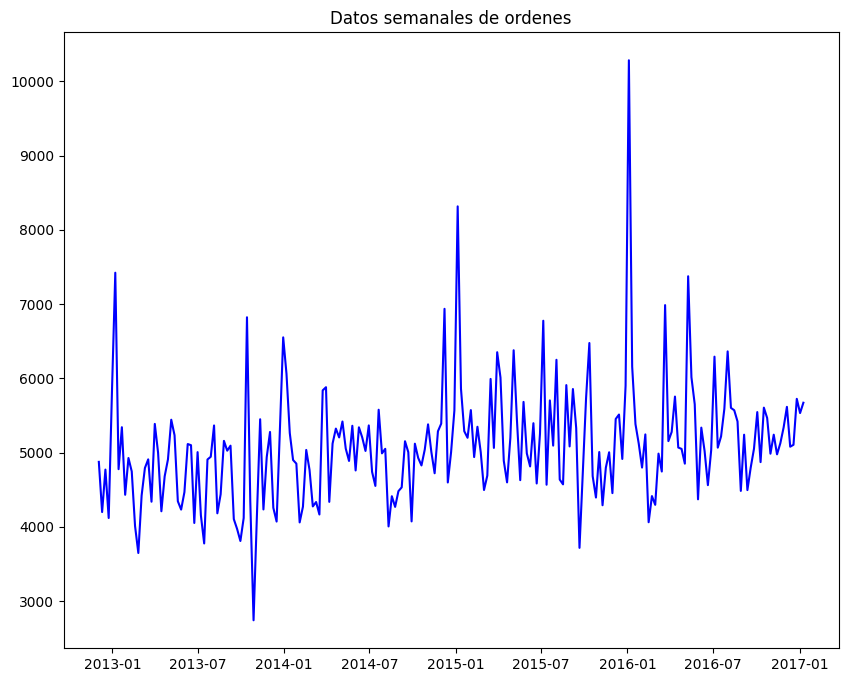

In [156]:
plt.figure(figsize=(10, 8))
plt.plot(y.index, y, label='Datos Originales', color='blue')
plt.title('Datos semanales de ordenes')
plt.show()

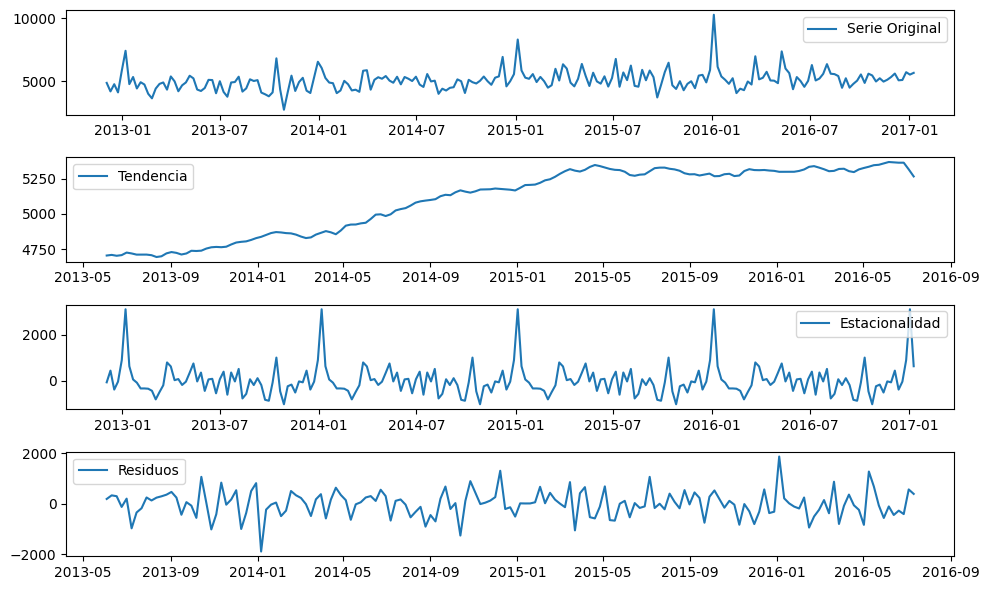

In [157]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(y, model='additive')

# Graficar los componentes
plt.figure(figsize=(10, 6))
plt.subplot(4, 1, 1)
plt.plot(y, label='Serie Original')
plt.legend()

plt.subplot(4, 1, 2)
plt.plot(result.trend, label='Tendencia')
plt.legend()

plt.subplot(4, 1, 3)
plt.plot(result.seasonal, label='Estacionalidad')
plt.legend()

plt.subplot(4, 1, 4)
plt.plot(result.resid, label='Residuos')
plt.legend()

plt.tight_layout()
plt.show()

- Lo primero que es notorio es que la tendencia es al alza sostenida desde 2013-09 hasta el 2015-04 donde alcanza una meseta más variable.
- Cada año se repite un patron ciclico en los datos donde siempre a principios de año hay un peak muy marcado de ordenes, lo que puede estar ligado algun tipo de promoción a fin de año. Posterior a esto bajan significativamente las ventas volviendo a tener un repunte significativamente mayor que el de principio de año y aún más variable. Considerando esto podemos considerar que cada 52 semanas hay un ciclo.

- Los residuos se encuentran bastante variables pero en general no dan signos más contundentes de seguir patrones

In [158]:
from statsmodels.tsa.stattools import adfuller

# Realizar el test de Dickey-Fuller
result = adfuller(y.values)
print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:', result[4])

ADF Statistic: -11.113799651305158
p-value: 3.604955327677591e-20
Critical Values: {'1%': -3.4612821203214907, '5%': -2.875142613826617, '10%': -2.574020122281422}


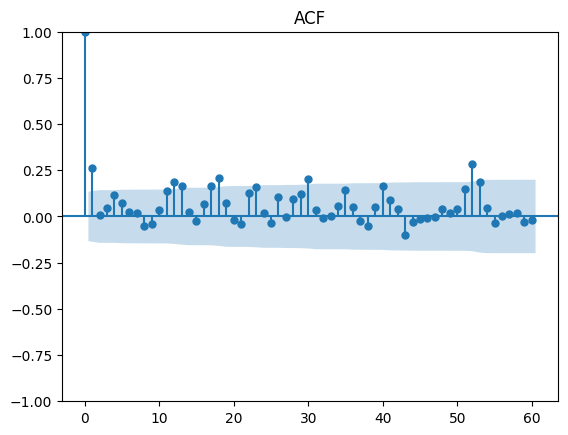

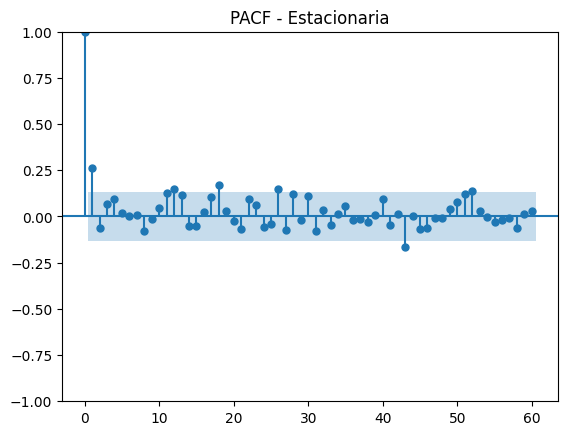

In [159]:
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import acf
from statsmodels.graphics.tsaplots import plot_pacf

plot_acf(y,  title="ACF", lags='60')
plt.show()
plot_pacf(y, title="PACF - Estacionaria", lags='60')
plt.show()

Tanto `ACF`(q) como `PACF`(p) muestra en sus LAGS alta correlaciones en diferentes momentos a lo largo del eje. La no existencia de decaimiento gradual en ninguno de los dos graficos además de en el gráfico anterior en su estacionaridad me hace concluir que necesitamos un modelo SARIMA, que incluya tanto diferenciacion en AR, MA, y en la componente Seasonal. 

Una diferenciacion anual en este caso en 52 semanas parece adecuada para intentar que los lags no se encuentren tan correlacionados con el primer lag. Ademas considerar que en 


In [160]:
from statsmodels.tsa.stattools import adfuller

# Realizar la prueba de Dickey-Fuller
adf_result = adfuller(y)
print(f'Estadístico ADF: {adf_result[0]}')
print(f'p-value: {adf_result[1]}')

Estadístico ADF: -11.113799651305158
p-value: 3.604955327677591e-20



**d**: Si bien nuestro test dice que la serie es estacionaria esto no implica que no existan correlaciones complejas o que la estacionalidad esté completamente removida por lo que hacer d=1 parece ser una buena idea. Otra razon para esto es reducir la varianza de la serie, simplificar AR/MA debido a que correlaciones persistentes generan ordenes de p y q más alto y al aplicar diferenciación nos aseguramos capar esto.

In [164]:
import statsmodels.api as sm

model = sm.tsa.SARIMAX(np.log1p(y), order=(1, 0, 1), seasonal_order= (1, 1, 0, 52))
results = model.fit()

# Pronóstico para los próximos 'n' pasos
n_pronostico = 52 # Ejemplo: pronóstico para las próximas 52 semanas
pronostico_sarima = results.get_forecast(steps=n_pronostico)
pronostico_intervalo = pronostico_sarima.conf_int()


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


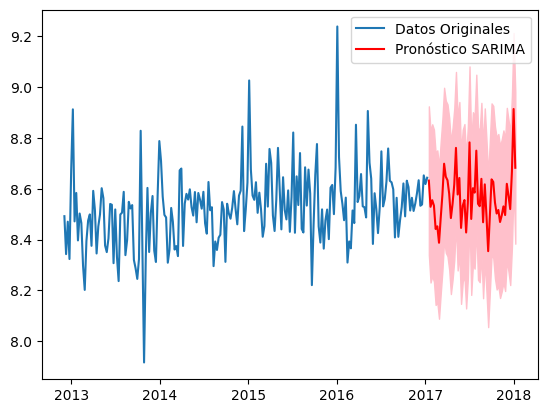

In [165]:

import matplotlib.pyplot as plt

plt.plot(np.log1p(y), label='Datos Originales')
plt.plot(pronostico_sarima.predicted_mean, color='red', label='Pronóstico SARIMA')
plt.fill_between(pronostico_intervalo.index, pronostico_intervalo.iloc[:, 0], pronostico_intervalo.iloc[:, 1], color='pink')
plt.legend()
plt.show()

In [166]:
y = np.log1p(y)

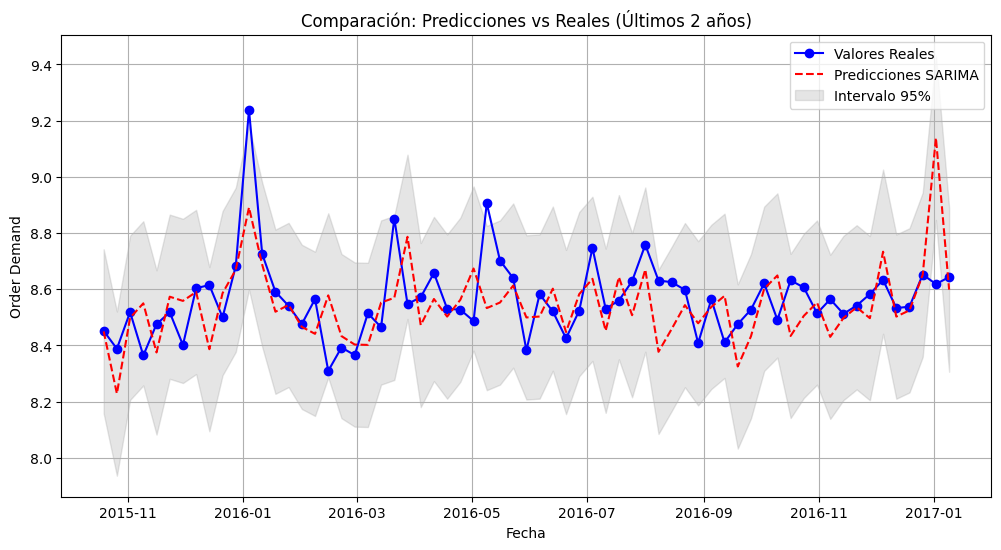

MAE: 0.11
RMSE: 0.15


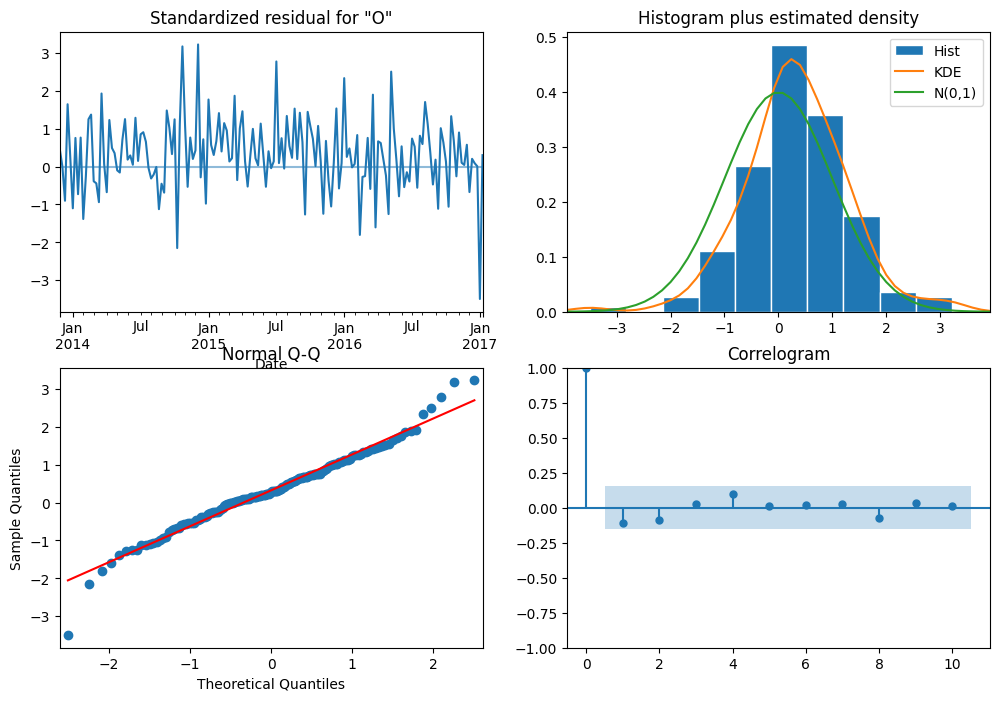

In [167]:
# Definir el rango de los últimos 2 años (ajusta las fechas según tus datos)
start_date = y.index[150]  # Fecha inicial de los últimos 2 años
end_date = y.index[-1]  # Última fecha disponible

# Obtener predicciones dentro de la muestra para el rango deseado
predictions = results.get_prediction(
    start=start_date, 
    end=end_date, 
    dynamic=False  # Predicciones estáticas (no recursivas)
)

# Extraer valores predichos y reales
predichos = predictions.predicted_mean
reales = y.loc[start_date:end_date]
intervalos = predictions.conf_int()


plt.figure(figsize=(12, 6))

# Graficar datos reales
plt.plot(reales, label='Valores Reales', color='blue', marker='o')

# Graficar predicciones
plt.plot(predichos, label='Predicciones SARIMA', color='red', linestyle='--')

# Rellenar intervalo de confianza
plt.fill_between(
    intervalos.index,
    intervalos.iloc[:, 0],
    intervalos.iloc[:, 1],
    color='gray',
    alpha=0.2,
    label='Intervalo 95%'
)

plt.title('Comparación: Predicciones vs Reales (Últimos 2 años)')
plt.xlabel('Fecha')
plt.ylabel('Order Demand')
plt.legend()
plt.grid(True)
plt.show()


from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calcular MAE y RMSE
mae = mean_absolute_error(reales, predichos)
rmse = np.sqrt(mean_squared_error(reales, predichos))

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')

results.plot_diagnostics(figsize=(12, 8))
plt.show()

In [ ]:
import pmdarima as pm
from pmdarima.model_selection import train_test_split
import pandas as pd

# Cargar tu serie temporal (y debe ser una Serie de pandas con índice datetime)
# y = df['Order_Demand'].resample('W-MON').mean().ffill()

# Dividir en train/test (opcional para validación)
train, test = train_test_split(y, test_size=104)  # Últimos 2 años como test

# Búsqueda automática de parámetros SARIMA
model = pm.auto_arima(
    train,
    seasonal=True,           # Activar componente estacional
    m=52,                    # Estacionalidad anual (52 semanas)
    start_p=0,               # Valor mínimo de p (AR no estacional)
    start_q=0,               # Valor mínimo de q (MA no estacional)
    max_p=3,                 # Máximo valor de p a probar
    max_q=3,                 # Máximo valor de q a probar
    d=None,                  # Dejar que el modelo determine d automáticamente
    start_P=0,               # Valor mínimo de P (AR estacional)
    start_Q=0,               # Valor mínimo de Q (MA estacional)
    max_P=2,                 # Máximo valor de P a probar
    max_Q=2,                 # Máximo valor de Q a probar
    D=1,                     # Diferenciación estacional fija (D=1)
    trace=True,              # Mostrar progreso en consola
    error_action='ignore',   # Ignorar combinaciones no convergentes
    suppress_warnings=True,  # Suprimir advertencias
    stepwise=True,           # Usar enfoque paso a paso para acelerar la búsqueda
    information_criterion='aic',  # Criterio de selección (AIC o BIC)
    n_jobs=-1                # Usar todos los núcleos del CPU
)

# Resultados
print(model.summary())

c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\pmdarima\arima\_validation.py:76: UserWarning: stepwise model cannot be fit in parallel (n_jobs=1). Falling back to stepwise parameter search.
  warnings.warn('stepwise model cannot be fit in parallel (n_jobs=%i). '
c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
c:\Users\kev_g\AppData\Loca

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,1,0)[52] intercept   : AIC=-37.001, Time=0.32 sec


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,1,0)[52] intercept   : AIC=-35.756, Time=9.03 sec


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

 ARIMA(0,0,1)(1,1,0)[52] intercept   : AIC=-35.812, Time=9.20 sec


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,1)(1,1,0)[52] intercept   : AIC=-35.803, Time=20.35 sec


c:\Users\kev_g\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(0,0,0)(1,1,0)[52]             : AIC=-30.500, Time=4.03 sec

Best model:  ARIMA(0,0,0)(1,1,0)[52] intercept
Total fit time: 100.323 seconds
                                SARIMAX Results                                 
Dep. Variable:                        y   No. Observations:                  111
Model:             SARIMAX(1, 1, 0, 52)   Log Likelihood                  21.854
Date:                  Fri, 28 Mar 2025   AIC                            -37.708
Time:                          16:17:06   BIC                            -31.475
Sample:                      12-03-2012   HQIC                           -35.275
                           - 01-12-2015                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      0.0986      0.041      2.408     

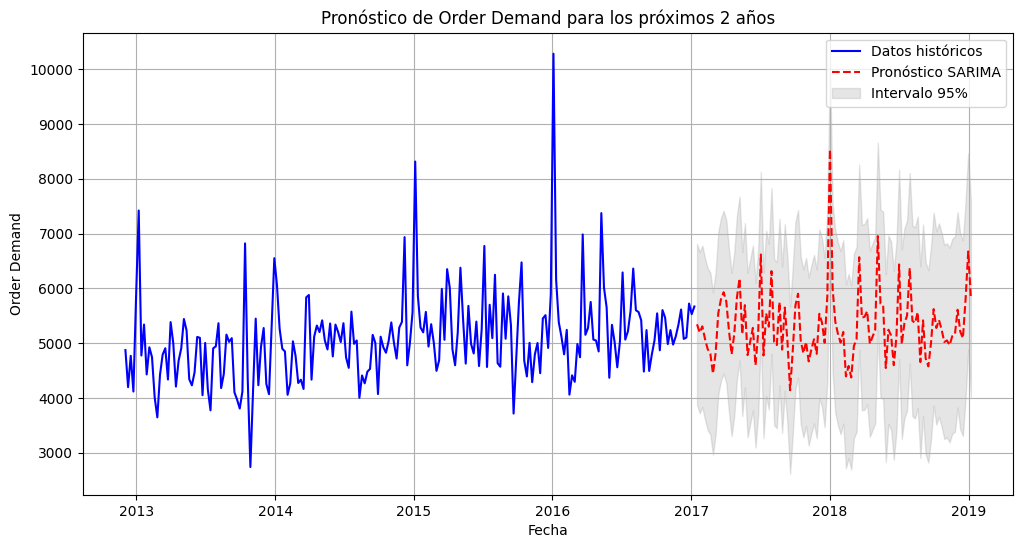

In [ ]:
# Pronosticar 104 pasos (semanas) hacia el futuro
n_pronostico = 104  # 2 años = 52 semanas/año * 2
pronostico = results.get_forecast(steps=n_pronostico)

# Obtener intervalos de confianza y valores predichos
pronostico_medio = pronostico.predicted_mean
pronostico_intervalo = pronostico.conf_int()


# Obtener la última fecha del conjunto de datos original
ultima_fecha = y.index[-1]

# Generar rango de fechas futuras (semanal, empezando desde la última fecha + 1 semana)
fechas_futuras = pd.date_range(
    start=ultima_fecha + pd.Timedelta(weeks=1),  # Evita solapamiento con el último dato
    periods=n_pronostico,
    freq='W-MON'  # Misma frecuencia que el resampleo original (ej: semanas que empiezan en lunes)
)

# Asignar fechas al pronóstico
pronostico_medio.index = fechas_futuras
pronostico_intervalo.index = fechas_futuras



plt.figure(figsize=(12, 6))

# Graficar datos históricos
plt.plot(y, label='Datos históricos', color='blue')

# Graficar pronóstico
plt.plot(pronostico_medio, label='Pronóstico SARIMA', color='red', linestyle='--')

# Rellenar intervalo de confianza
plt.fill_between(
    pronostico_intervalo.index,
    pronostico_intervalo.iloc[:, 0],
    pronostico_intervalo.iloc[:, 1],
    color='gray',
    alpha=0.2,
    label='Intervalo 95%'
)

plt.title('Pronóstico de Order Demand para los próximos 2 años')
plt.xlabel('Fecha')
plt.ylabel('Order Demand')
plt.legend()
plt.grid(True)
plt.show()


# Crear DataFrame con el pronóstico
df_pronostico = pd.DataFrame({
    'Fecha': fechas_futuras,
    'Pronostico': pronostico_medio,
    'Limite_Inferior': pronostico_intervalo.iloc[:, 0],
    'Limite_Superior': pronostico_intervalo.iloc[:, 1]
}).set_index('Fecha')

# Guardar en CSV
df_pronostico.to_csv('pronostico_sarima_2años.csv')